<a href="https://colab.research.google.com/github/Sydney205/oulad-student-dropout-prediction/blob/main/OULAD_Student_Dropout_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Dropout Prediction Using OULAD Dataset 📚

## Project Overview
Student dropout is a major challenge in online education. This project explores whether student engagement, academic performance, and demographic information can help predict which students are at risk of withdrawing from a course. The objective is not only to build a machine learning model, but also to understand the behavioral patterns associated with dropout.

### Key Question
Can student behavior in online learning environments predict dropout risk early enough for intervention?

## Importing Required Libraries
This section imports the tools needed for:
- data manipulation
- visualization
- exploratory data analysis

Libraries such as Pandas and NumPy are used for data preparation, while Matplotlib and Seaborn are used for visualization.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset
The dataset used is the **Open University Learning Analytics Dataset (OULAD)**. OULAD contains anonymized student information, assessment records, and online learning activity data from an online learning platform. This dataset was selected because it combines:
- demographic information
- engagement behavior
- academic performance

These are strong signals for understanding student dropout behavior.

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")
print(path)

Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.
/kaggle/input/student-demographics-online-education-dataoulad


In [ ]:
files = os.listdir(path)
print(files)

['studentRegistration.csv', 'studentAssessment.csv', 'studentInfo.csv', 'studentVle.csv', 'vle.csv', 'assessments.csv', 'courses.csv']


## Loading Individual Tables
The OULAD dataset is split into multiple relational tables. Instead of using all tables directly, only the most relevant tables for dropout prediction are selected:
- **studentInfo** → student demographics and final outcomes
- **studentVle** → engagement data (click activity)
- **studentAssessment** → student academic performance

This selective approach reduces noise and keeps the analysis focused on variables most relevant to dropout risk.

In [ ]:
student_assess= pd.read_csv(f"{path}/studentAssessment.csv")
student_assess.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [ ]:
student_vle= pd.read_csv(f"{path}/studentVle.csv")
student_vle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [ ]:
student_info= pd.read_csv(f"{path}/studentInfo.csv")
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [ ]:
assessment = pd.read_csv(f"{path}/assessments.csv")
assessment.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [ ]:
vle = pd.read_csv(f"{path}/vle.csv")
vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [ ]:
courses = pd.read_csv(f"{path}/courses.csv")
courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [ ]:
student_regis = pd.read_csv(f"{path}/studentRegistration.csv")
student_regis.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


## Feature Engineering
The raw dataset contains multiple rows per student because students interact with the learning system many times. Machine learning models require one row per student. To solve this:
- click activity is aggregated into total engagement
- assessment scores are summarized into average academic performance

This transforms event-level data into student-level behavioral summaries.

### Aggregating Student Engagement
The `studentVle` table records every click made by students. Since students can generate many click records, total clicks are aggregated per student.

Why total clicks?
- captures engagement intensity
- low activity often signals disengagement
- disengagement is strongly linked to dropout risk

In [ ]:
vle_features = student_vle.groupby('id_student').agg({
    "sum_click": "sum"
}).reset_index()

### Aggregating Academic Performance

Students complete multiple assessments during a course, resulting in multiple score records per student.

To prepare the data for modeling, these scores are summarized into one student-level metric.

The **median score** is used instead of the mean because score distributions may be skewed by unusually high or low results.

Why median?
- less sensitive to outliers
- provides a more robust measure of typical student performance
- better reflects central tendency when score distributions are uneven

This makes the feature more stable for predictive modeling.

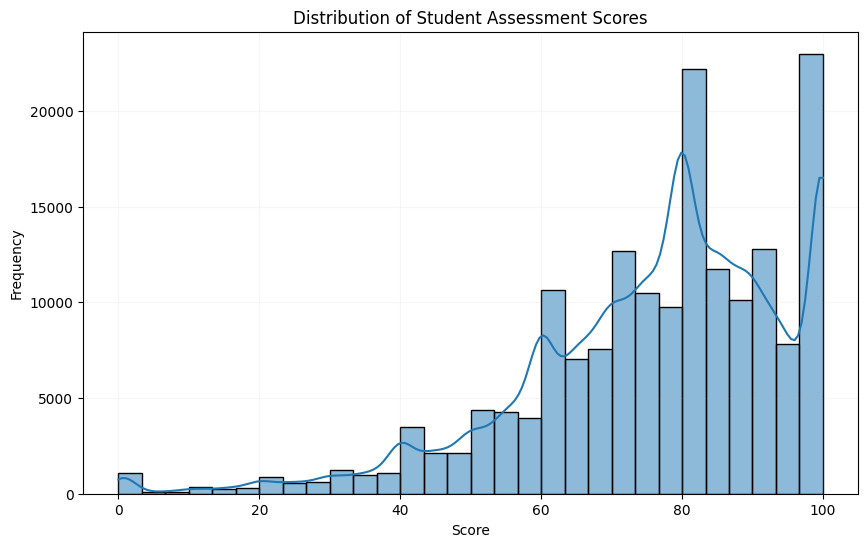

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(student_assess['score'], bins=30, kde=True)
plt.title('Distribution of Student Assessment Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.1)
plt.show()

### Insight: Student Score Distribution

The histogram above shows the distribution of all individual student assessment scores. We can observe that the distribution is slightly skewed to the left, and there might be some outliers on the lower end (scores of 0).

This skewed nature, along with the presence of potential outliers, reinforces the decision to use the **median score** for aggregating academic performance. The median is less sensitive to extreme values compared to the mean, providing a more representative measure of a student's typical performance throughout the course.

In [ ]:
assessment_features = student_assess.groupby("id_student").agg({
    "score": "median" # Median is used here as it is more robust to skewed distributions and outliers in student scores.
}).reset_index()

## Building the Master Student Dataset
The selected tables are merged into one student-level analytical dataset. This combines:
- student background information
- online engagement
- academic performance

The result is a single table suitable for exploratory analysis and machine learning.

In [ ]:
student_df = student_info.merge(vle_features, on="id_student", how="left")

In [ ]:
student_df = student_df.merge(assessment_features, on="id_student", how="left")

## Initial Data Inspection
Before analysis, the dataset structure is inspected to understand:
- number of observations
- feature types
- missing values
- overall data quality

This step ensures the dataset is ready for preprocessing.

In [ ]:
student_df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,sum_click,score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,82.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,68.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,74.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,63.0


In [ ]:
print(f"Data shape: {student_df.shape}\n")
student_df.info()

Data shape: (32593, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              31482 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  sum_click             29741 non-null  float64
 13  score                 26727 non-null  float64
dtypes: float64(2), int64(3), object(9)
memory usa

In [ ]:
student_df.describe()

,id_student,num_of_prev_attempts,studied_credits,sum_click,score
count,3.259300e+04,32593.000000,32593.000000,29741.000000,26727.000000
mean,7.066877e+05,0.163225,79.758691,1620.864665,73.759214
std,5.491673e+05,0.479758,41.071900,2050.309532,16.038393
min,3.733000e+03,0.000000,30.000000,1.000000,0.000000
25%,5.085730e+05,0.000000,60.000000,324.000000,65.000000
50%,5.903100e+05,0.000000,60.000000,903.000000,77.000000
75%,6.444530e+05,0.000000,120.000000,2171.000000,85.000000
max,2.716795e+06,6.000000,655.000000,28615.000000,100.000000


## Missing Value Analysis
Missing values are not treated as errors by default. In educational data, missingness can be meaningful. Examples:
- missing clicks may indicate no platform activity
- missing scores may indicate no submission

This makes missing values behaviorally informative.

In [ ]:
student_df.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


## Handling Missing Values
Different variables are treated differently based on their meaning.

### Click Activity (`sum_click`)
Missing values are filled with 0 because no recorded activity likely indicates no engagement.

### Assessment Scores (`score`)
Missing values are filled with 0 because missing scores often represent missed submissions.

### IMD Band (`imd_band`)
Missing values are replaced with `"Unknown"` since this is categorical socioeconomic information and should not be forced into numeric assumptions.

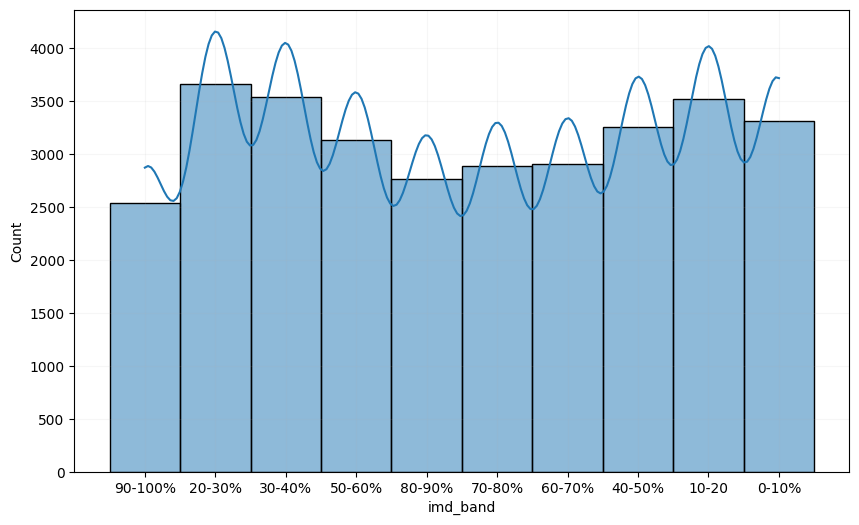

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=student_df, x='imd_band', bins=10, kde=True)
plt.grid(True, alpha=0.1)
plt.show()

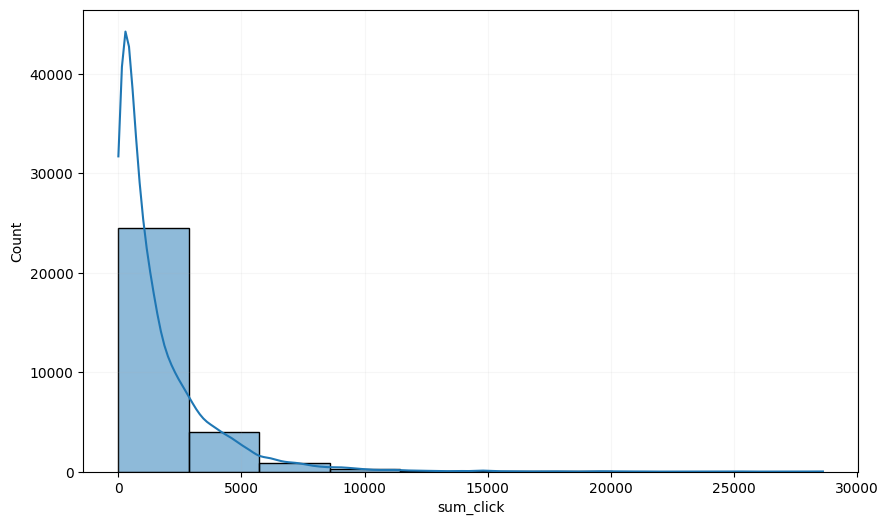

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=student_df, x='sum_click', bins=10, kde=True)
plt.grid(True, alpha=0.1)
plt.show()

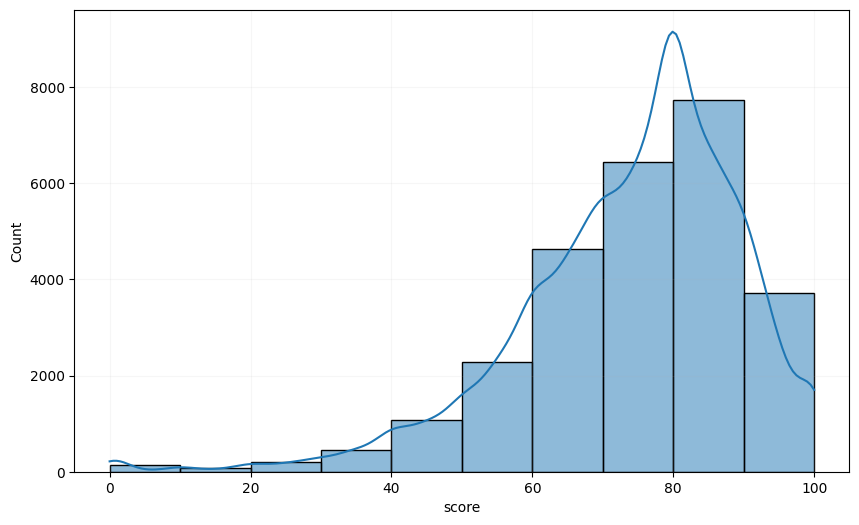

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=student_df, x='score', bins=10, kde=True)
plt.grid(True, alpha=0.1)
plt.show()

In [ ]:
student_df["sum_click"] = student_df["sum_click"].fillna(0)

In [ ]:
student_df["score"] = student_df["score"].fillna(0)

In [ ]:
student_df["imd_band"] = student_df["imd_band"].fillna("Unknown")

In [ ]:
student_df.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,0
age_band,0
num_of_prev_attempts,0
studied_credits,0


## Creating the Target Variable
The target variable is derived from `final_result`. Students labeled as:
- **Withdrawn** → dropout = 1

All other outcomes:
- Pass
- Fail
- Distinction

are grouped as non-dropout (0). This converts the problem into binary classification.

In [ ]:
student_df["dropout"] = (student_df["final_result"] == "Withdrawn").astype(int)

# Exploratory Data Analysis (EDA) 📊
This section explores relationships between:
- engagement
- academic performance
- student background factors
- dropout outcomes

The goal is to identify meaningful patterns before model training.

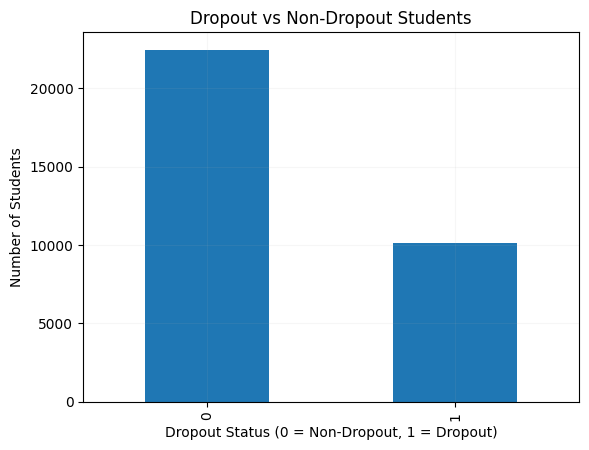

In [ ]:
student_df["dropout"].value_counts().plot(kind="bar")
plt.title("Dropout vs Non-Dropout Students")
plt.xlabel("Dropout Status (0 = Non-Dropout, 1 = Dropout)")
plt.ylabel("Number of Students")
plt.grid(True, alpha=0.1)
plt.show()

### Insight
The dataset is imbalanced, with more students completing courses than withdrawing. This is expected in real-world dropout prediction problems and should be considered during model training.

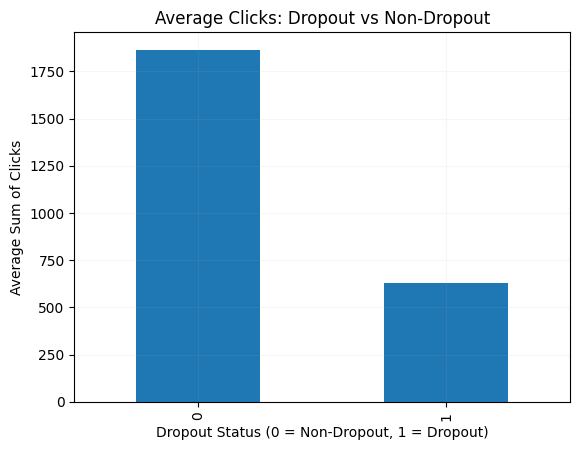

In [ ]:
student_df.groupby("dropout")["sum_click"].mean().plot(kind="bar")
plt.title("Average Clicks: Dropout vs Non-Dropout")
plt.xlabel("Dropout Status (0 = Non-Dropout, 1 = Dropout)")
plt.ylabel("Average Sum of Clicks")
plt.grid(True, alpha=0.1)
plt.show()

### Insight
Students who withdrew generally show lower click activity. This suggests that platform engagement may be a strong early warning signal for dropout risk.

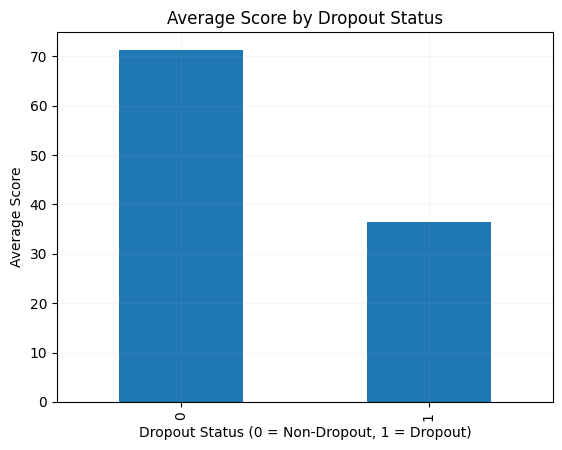

In [ ]:
student_df.groupby("dropout")["score"].mean().plot(kind="bar")
plt.title("Average Score by Dropout Status")
plt.xlabel("Dropout Status (0 = Non-Dropout, 1 = Dropout)")
plt.ylabel("Average Score")
plt.grid(True, alpha=0.1)
plt.show()

### Insight
Students with lower average scores are more likely to withdraw. Academic performance appears strongly associated with student retention.

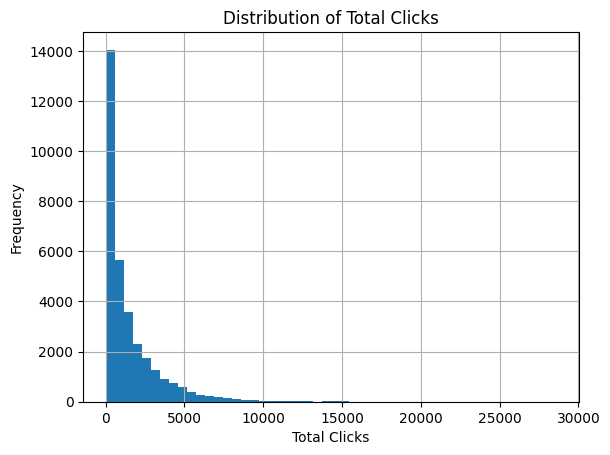

In [ ]:
student_df["sum_click"].hist(bins=50)
plt.title("Distribution of Total Clicks")
plt.xlabel("Total Clicks")
plt.ylabel("Frequency")
plt.show()

### Correlation Analysis
The heatmap helps identify relationships between numerical features. Particular attention is paid to:
- click activity
- scores
- dropout status

These relationships help guide feature selection for modeling.

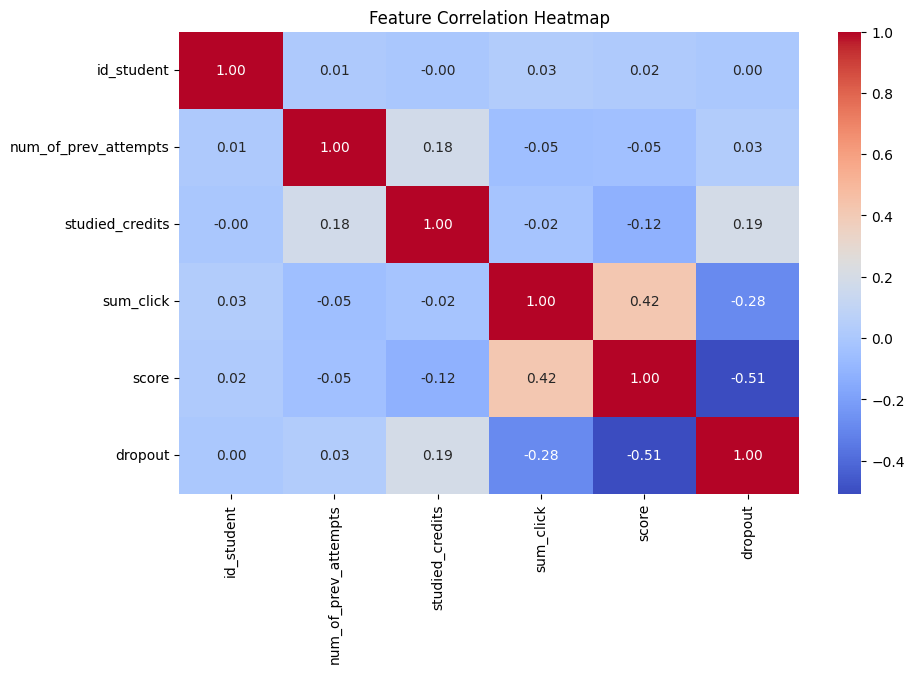

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(student_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

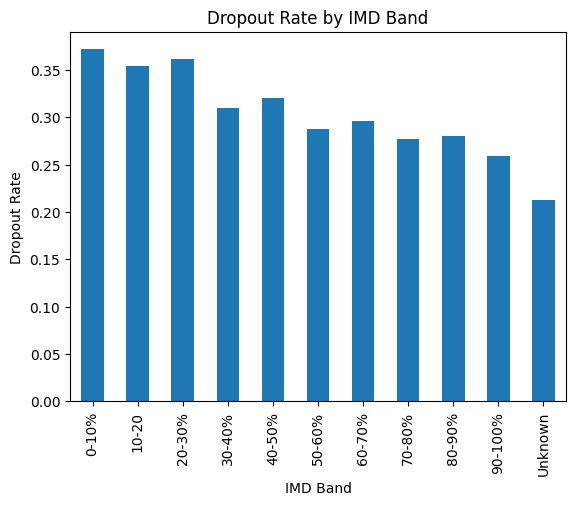

In [ ]:
student_df.groupby("imd_band")["dropout"].mean().plot(kind="bar")
plt.title("Dropout Rate by IMD Band")
plt.xlabel("IMD Band")
plt.ylabel("Dropout Rate")
plt.show()

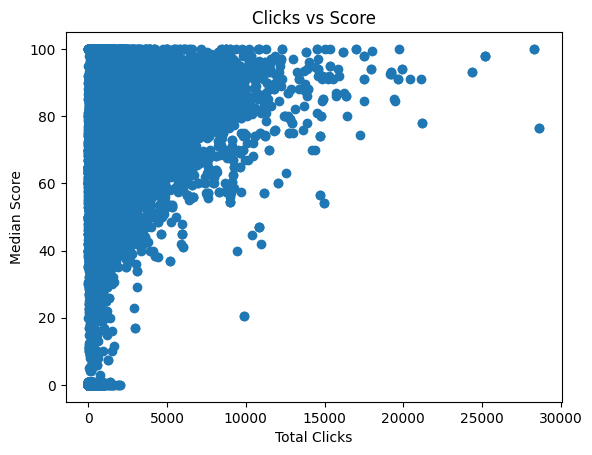

In [ ]:
plt.scatter(student_df["sum_click"], student_df["score"])
plt.title("Clicks vs Score")
plt.xlabel("Total Clicks")
plt.ylabel("Median Score")
plt.show()

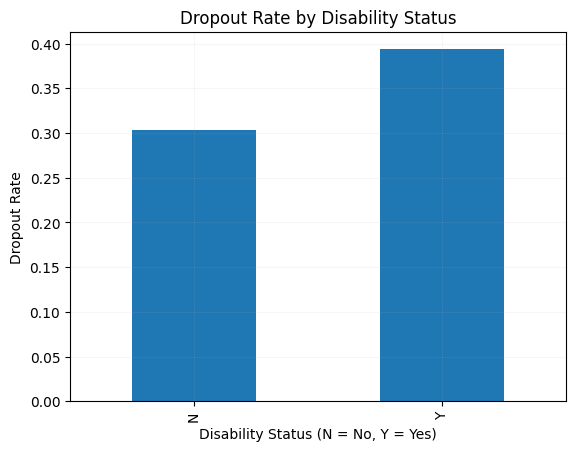

In [ ]:
student_df.groupby("disability")["dropout"].mean().plot(kind="bar")
plt.title("Dropout Rate by Disability Status")
plt.xlabel("Disability Status (N = No, Y = Yes)")
plt.ylabel("Dropout Rate")
plt.grid(True, alpha=0.1)
plt.show()

# Key Findings 🔍
From exploratory analysis:
- Lower engagement is strongly associated with dropout
- Lower academic performance aligns with higher withdrawal rates
- Missing activity and scores are behaviorally meaningful
- Socioeconomic background may contribute to dropout risk

## Next Steps
The next phase is to:
- encode categorical variables
- split training/testing data
- train classification models
- evaluate dropout prediction performance